# Notebook 01 — Exploratory Data Analysis (EDA)

**Project:** FUSE — Feature Unification for Semantic Exploration

**Objective:** Understand the TMDB movie dataset structure, distributions, text characteristics, and data quality before preprocessing.

**Key Questions:**
- What does the data look like? How many movies, what columns?
- How much missing data exists, especially in text fields?
- What are the distributions of genres, languages, release years?
- What do the text fields (overview, tagline, keywords) look like in terms of length, vocabulary, and content?

---

## 1.1 — Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── Color Theme ──
GOLD = '#eab308'
BLACK = '#050505'
WHITE = '#ffffff'
GRAY = '#888888'

# Global matplotlib style
plt.rcParams.update({
    'figure.facecolor': WHITE,
    'axes.facecolor': WHITE,
    'axes.edgecolor': BLACK,
    'axes.labelcolor': BLACK,
    'text.color': BLACK,
    'xtick.color': BLACK,
    'ytick.color': BLACK,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100
})

print('Setup complete.')

Setup complete.


In [2]:
df = pd.read_csv('../Artifacts/preprocessing/cleaned_movies.csv')
print(f'Dataset shape: {df.shape[0]} movies, {df.shape[1]} columns')
df.head(3)

Dataset shape: 27777 movies, 20 columns


,id,title,vote_average,vote_count,runtime,backdrop_path,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords,release_year
0,27205,Inception,8.364,34495,148,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,https://www.warnerbros.com/movies/inception,tt1375666,en,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",2010
1,157336,Interstellar,8.417,32571,169,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,http://www.interstellarmovie.net/,tt0816692,en,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",2014
2,155,The Dark Knight,8.512,30619,152,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,https://www.warnerbros.com/movies/dark-knight/,tt0468569,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",2008


## 1.2 — Data Overview and Missing Values

In [3]:
print('Column types:')
print(df.dtypes)
print(f'\nDuplicate rows: {df.duplicated().sum()}')
print(f'Duplicate titles: {df["title"].duplicated().sum()}')

Column types:
id                        int64
title                       str
vote_average            float64
vote_count                int64
runtime                   int64
backdrop_path               str
homepage                    str
imdb_id                     str
original_language           str
original_title              str
overview                    str
popularity              float64
poster_path                 str
tagline                     str
genres                      str
production_companies        str
production_countries        str
spoken_languages            str
keywords                    str
release_year              int64
dtype: object

Duplicate rows: 0
Duplicate titles: 1588


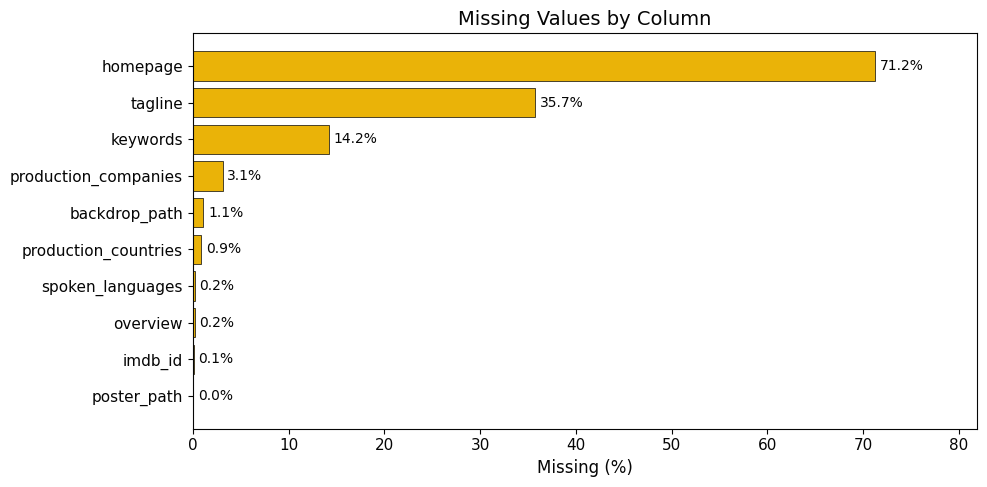


Key text fields missing values:
  overview: 52 (0.2%)
  tagline: 9905 (35.7%)
  keywords: 3950 (14.2%)


In [4]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'count': missing, 'percent': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('count', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_df.index, missing_df['percent'], color=GOLD, edgecolor=BLACK, linewidth=0.5)
for bar, pct in zip(bars, missing_df['percent']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=10, color=BLACK)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column')
ax.set_xlim(0, missing_df['percent'].max() * 1.15)
plt.tight_layout()
plt.show()

print('\nKey text fields missing values:')
for col in ['overview', 'tagline', 'keywords']:
    n = df[col].isna().sum()
    print(f'  {col}: {n} ({n/len(df)*100:.1f}%)')

## 1.3 — Numerical Distributions

We look at vote_average, vote_count, runtime, popularity, and release_year to understand the overall shape of the dataset.

In [5]:
num_cols = ['vote_average', 'vote_count', 'runtime', 'popularity', 'release_year']
df[num_cols].describe().round(2)

,vote_average,vote_count,runtime,popularity,release_year
count,27777.00,27777.00,27777.00,27777.00,27777.00
mean,6.41,707.45,99.55,14.57,2001.13
std,0.88,1914.22,26.31,40.31,21.42
min,1.84,50.00,1.00,0.60,1874.00
25%,5.86,80.00,90.00,6.67,1993.00
50%,6.47,153.00,98.00,9.71,2009.00
75%,7.02,446.00,111.00,14.77,2016.00
max,9.98,34495.00,298.00,2994.36,2023.00


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=50, color=GOLD, edgecolor=BLACK, linewidth=0.3, alpha=0.9)
    ax.set_title(col)
    ax.axvline(data.median(), color=BLACK, linestyle='--', linewidth=1, label=f'median={data.median():.1f}')
    ax.legend(fontsize=9)

axes[-1].axis('off')  # hide extra subplot
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 1.4 — Genre Analysis

Genres are comma-separated strings. We explode them to analyze individual genre frequency and co-occurrence.

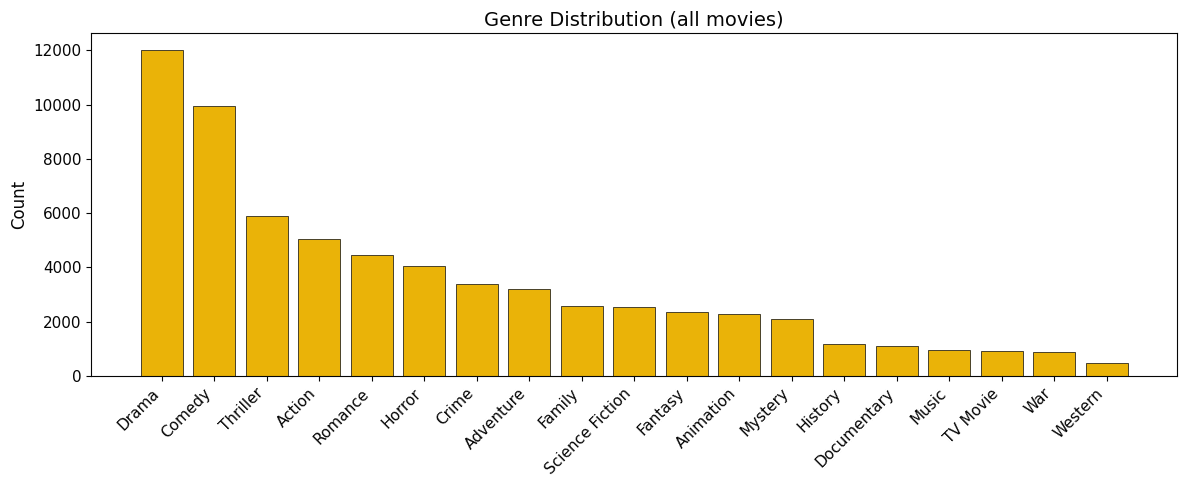

Total unique genres: 19
Average genres per movie: 2.4


In [7]:
# Explode genres
genres_series = df['genres'].str.split(', ').explode().str.strip()
genre_counts = genres_series.value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(genre_counts.index, genre_counts.values, color=GOLD, edgecolor=BLACK, linewidth=0.5)
ax.set_title('Genre Distribution (all movies)')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'Total unique genres: {genre_counts.shape[0]}')
print(f'Average genres per movie: {df["genres"].str.split(", ").apply(len).mean():.1f}')

In [ ]:
# Genre co-occurrence matrix (top 10)
top_genres = genre_counts.head(10).index.tolist()

cooc = pd.DataFrame(0, index=top_genres, columns=top_genres)
for _, row in df.iterrows():
    g = [x.strip() for x in str(row['genres']).split(',') if x.strip() in top_genres]
    for i in range(len(g)):
        for j in range(i+1, len(g)):
            cooc.loc[g[i], g[j]] += 1
            cooc.loc[g[j], g[i]] += 1

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cooc.values, cmap='YlOrBr', aspect='auto')
ax.set_xticks(range(len(top_genres)))
ax.set_yticks(range(len(top_genres)))
ax.set_xticklabels(top_genres, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(top_genres, fontsize=9)
for i in range(len(top_genres)):
    for j in range(len(top_genres)):
        val = cooc.values[i, j]
        if val > 0:
            color = WHITE if val > cooc.values.max() * 0.6 else BLACK
            ax.text(j, i, str(val), ha='center', va='center', fontsize=7, color=color)
ax.set_title('Genre Co-occurrence (Top 10 Genres)')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 1.5 — Language Distribution

In [ ]:
lang_counts = df['original_language'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lang_counts.index, lang_counts.values, color=GOLD, edgecolor=BLACK, linewidth=0.5)
ax.set_title('Top 15 Original Languages')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

en_pct = (df['original_language'] == 'en').sum() / len(df) * 100
print(f'English movies: {en_pct:.1f}% of the dataset')

## 1.6 — Release Year Trends

In [ ]:
year_counts = df['release_year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(year_counts.index, year_counts.values, color=GOLD, alpha=0.6)
ax.plot(year_counts.index, year_counts.values, color=BLACK, linewidth=1)
ax.set_title('Number of Movies by Release Year')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.set_xlim(1900, 2024)
plt.tight_layout()
plt.show()

print(f'Peak year: {year_counts.idxmax()} with {year_counts.max()} movies')

## 1.7 — Text Field Analysis

The NLP core of this project relies on three text fields: `overview`, `tagline`, and `keywords`. We analyze their length distributions, vocabulary, and content patterns.

In [11]:
# Text length statistics
for col in ['overview', 'tagline', 'keywords']:
    text = df[col].dropna().astype(str)
    word_counts = text.str.split().apply(len)
    char_counts = text.str.len()
    print(f'--- {col} ---')
    print(f'  Available: {len(text)} / {len(df)} ({len(text)/len(df)*100:.1f}%)')
    print(f'  Word count — mean: {word_counts.mean():.1f}, median: {word_counts.median():.0f}, max: {word_counts.max()}')
    print(f'  Char count — mean: {char_counts.mean():.0f}, median: {char_counts.median():.0f}')
    print()

--- overview ---
  Available: 27725 / 27777 (99.8%)
  Word count — mean: 47.5, median: 41, max: 186
  Char count — mean: 278, median: 240

--- tagline ---
  Available: 17872 / 27777 (64.3%)
  Word count — mean: 7.8, median: 7, max: 47
  Char count — mean: 43, median: 37

--- keywords ---
  Available: 23827 / 27777 (85.8%)
  Word count — mean: 12.1, median: 10, max: 134
  Char count — mean: 94, median: 74



In [ ]:
# Word count distributions for text fields
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['overview', 'tagline', 'keywords']):
    text = df[col].dropna().astype(str)
    word_counts = text.str.split().apply(len)
    axes[i].hist(word_counts, bins=40, color=GOLD, edgecolor=BLACK, linewidth=0.3)
    axes[i].set_title(f'{col} — word count')
    axes[i].axvline(word_counts.median(), color=BLACK, linestyle='--', linewidth=1)

fig.suptitle('Text Length Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 1.8 — Vocabulary and Token Frequency

In [13]:
import re

def simple_tokenize(text):
    """Lowercase and split on non-alphanumeric characters."""
    return re.findall(r'[a-z]+', text.lower())

# Build vocabulary from overview
all_tokens = []
for text in df['overview'].dropna():
    all_tokens.extend(simple_tokenize(str(text)))

token_freq = Counter(all_tokens)
print(f'Total tokens in overviews: {len(all_tokens):,}')
print(f'Unique tokens (vocabulary): {len(token_freq):,}')
print(f'\nTop 20 most frequent words:')
for word, count in token_freq.most_common(20):
    print(f'  {word}: {count}')

Total tokens in overviews: 1,343,596
Unique tokens (vocabulary): 47,741

Top 20 most frequent words:
  the: 72188
  a: 58192
  to: 43045
  and: 39088
  of: 36793
  in: 25349
  his: 20877
  is: 17970
  s: 14684
  with: 13135
  her: 12950
  he: 11585
  for: 10220
  an: 10179
  on: 9601
  that: 8606
  their: 8440
  by: 7867
  who: 7642
  as: 7567


In [ ]:
# Top 30 words bar chart (excluding common stopwords for a cleaner view)
basic_stops = {'the', 'a', 'an', 'and', 'of', 'to', 'in', 'is', 'his', 'her',
               'he', 'she', 'it', 'for', 'with', 'on', 'as', 'at', 'by', 'from',
               'that', 'this', 'but', 'are', 'was', 'be', 'has', 'who', 'their',
               'they', 'not', 'have', 'been', 'its', 'when', 'will', 'or', 'into',
               'after', 'up', 'out', 'about', 'all', 'one', 'can', 'more', 'had'}

filtered = {w: c for w, c in token_freq.items() if w not in basic_stops and len(w) > 2}
top30 = Counter(filtered).most_common(30)
words, counts = zip(*top30)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(words, counts, color=GOLD, edgecolor=BLACK, linewidth=0.3)
ax.set_title('Top 30 Words in Overviews (stopwords excluded)')
ax.set_ylabel('Frequency')
plt.xticks(rotation=50, ha='right')
plt.tight_layout()
plt.show()

## 1.9 — Bigram Analysis

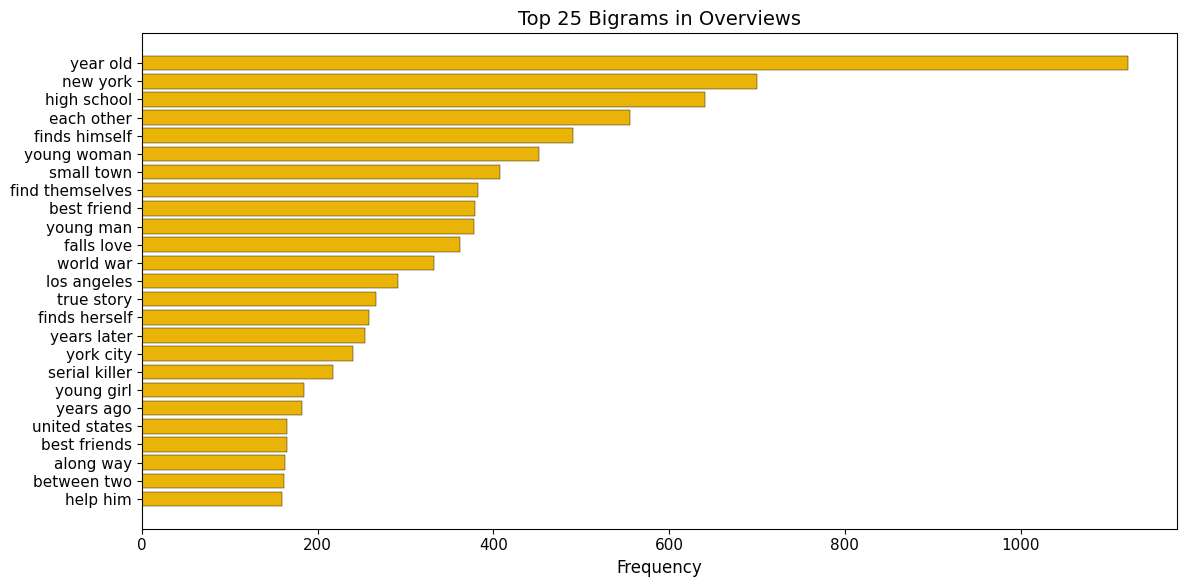

In [15]:
from itertools import islice

def get_bigrams(text, stops):
    tokens = [t for t in simple_tokenize(text) if t not in stops and len(t) > 2]
    return list(zip(tokens, tokens[1:]))

bigram_counter = Counter()
for text in df['overview'].dropna():
    bigram_counter.update(get_bigrams(str(text), basic_stops))

top25_bigrams = bigram_counter.most_common(25)
labels = [f'{a} {b}' for (a, b), _ in top25_bigrams]
vals = [c for _, c in top25_bigrams]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(labels[::-1], vals[::-1], color=GOLD, edgecolor=BLACK, linewidth=0.3)
ax.set_title('Top 25 Bigrams in Overviews')
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.show()

## 1.10 — Keyword Analysis

Total keyword occurrences: 181,919
Unique keywords: 21,873

Keywords per movie — mean: 7.6, median: 6


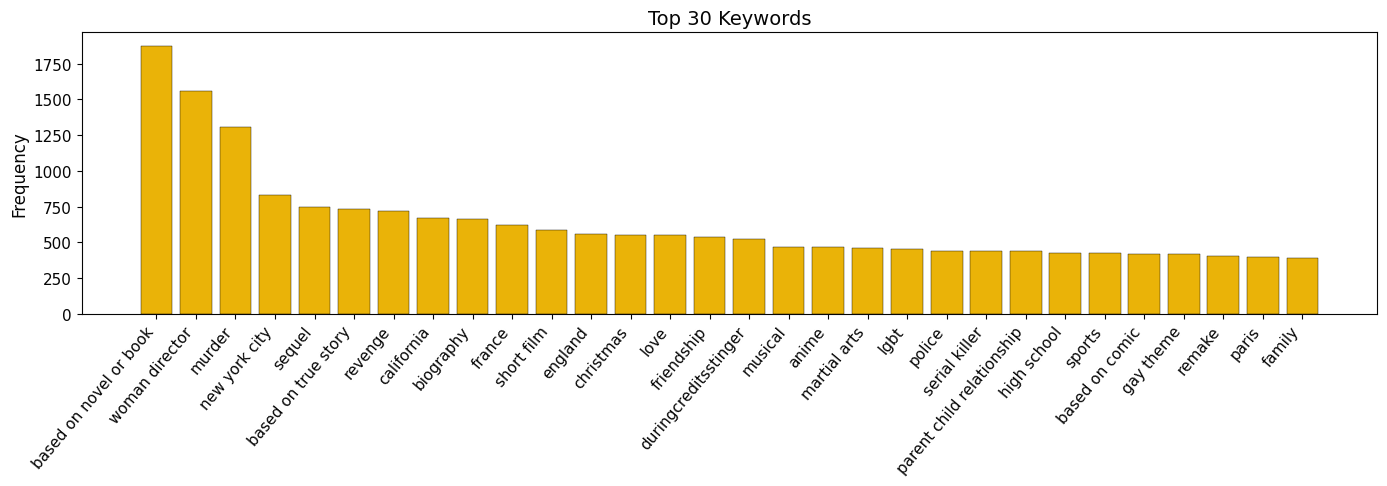

In [16]:
# Keyword frequency
all_keywords = []
for kw in df['keywords'].dropna():
    all_keywords.extend([k.strip().lower() for k in str(kw).split(',')])

kw_freq = Counter(all_keywords)
print(f'Total keyword occurrences: {len(all_keywords):,}')
print(f'Unique keywords: {len(kw_freq):,}')

# Keywords per movie
kw_per_movie = df['keywords'].dropna().str.split(',').apply(len)
print(f'\nKeywords per movie — mean: {kw_per_movie.mean():.1f}, median: {kw_per_movie.median():.0f}')

# Top 30 keywords
top30_kw = kw_freq.most_common(30)
kw_names, kw_counts = zip(*top30_kw)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(kw_names, kw_counts, color=GOLD, edgecolor=BLACK, linewidth=0.3)
ax.set_title('Top 30 Keywords')
ax.set_ylabel('Frequency')
plt.xticks(rotation=50, ha='right')
plt.tight_layout()
plt.show()

## 1.11 — Correlation Between Numerical Features

In [ ]:
corr = df[['vote_average', 'vote_count', 'runtime', 'popularity', 'release_year']].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap='YlOrBr', vmin=-1, vmax=1)
labels = corr.columns
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(labels, fontsize=9)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=9,
                color=WHITE if abs(corr.values[i,j]) > 0.5 else BLACK)
ax.set_title('Correlation Matrix — Numerical Features')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 1.12 — Vote Average by Genre

In [ ]:
# Average rating per genre
genre_expanded = df[['vote_average', 'genres']].copy()
genre_expanded['genres'] = genre_expanded['genres'].str.split(', ')
genre_expanded = genre_expanded.explode('genres')

genre_avg = genre_expanded.groupby('genres')['vote_average'].agg(['mean', 'count'])
genre_avg = genre_avg[genre_avg['count'] >= 50].sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(genre_avg.index, genre_avg['mean'], color=GOLD, edgecolor=BLACK, linewidth=0.5)
ax.set_xlabel('Mean Vote Average')
ax.set_title('Average Rating by Genre (min 50 movies)')
ax.axvline(df['vote_average'].mean(), color=GRAY, linestyle='--', label=f'Overall mean: {df["vote_average"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

## 1.13 — Summary & Takeaways

**Dataset size:** ~27,777 movies with 20 columns.

**Missing data:**
- `homepage` (71%) and `tagline` (36%) have significant missingness. Tagline will be used when available but is not required.
- `overview` is nearly complete (only 52 missing) — this is our primary text source.
- `keywords` is missing for ~14% of movies.

**Text characteristics:**
- Overviews average ~35 words — short summaries, good for TF-IDF and sentence embeddings.
- Keywords are comma-separated phrases, averaging ~7 per movie — structured and useful.
- Taglines are very short (5-10 words) — stylistic rather than informational.

**Genre landscape:** Drama dominates heavily, followed by Comedy and Thriller. Most movies have 2-3 genres.

**Language:** ~66% English. We will focus on English-language movies for NLP quality.

**Next step:** Notebook 02 — Text Preprocessing (tokenization, lemmatization, combined text field creation).